# SE Factory AIE Bootcamp — Week 6, Day 1
## Deep Learning Fundamentals: An MLP From Scratch on Pets

**Objective:** Build the smallest possible neural network — a 2-layer
MLP — *by hand* in NumPy. Forward pass, loss, backward pass, gradient
descent. No PyTorch, no autograd, no shortcuts. By the end of tonight
you will have trained a model end-to-end and discovered something
important: *the math works (loss drops, gradients are correct), but
on this representation the model just barely matches the trivial
always-dog baseline*. That's not a bug — it's the lesson. The math
is necessary; it isn't sufficient. Days 2-4 will fix that.

**Dataset:** Oxford-IIIT Pet Dataset (37 breeds, 7,349 images). Tonight
we collapse the 37 breeds into a binary cat / dog target, downsample
each image to 32x32 grayscale, and flatten it to a 1024-D vector.
Tomorrow we move to PyTorch and the full 37-class breed problem;
Wednesday we learn proper image handling; Thursday we wire up
pretrained models for classification + detection + segmentation. The
same dataset carries us all four days.

**Self-contained:** torchvision downloads the dataset on first run
(~800 MB, cached for the runtime's lifetime). No upload prompt, no
joblib, no prior-day artifact. Day 1 has no recap because there are
no prior days to recap.

**What this notebook does *not* do:** call `torch.nn.Module`, use
`loss.backward()`, or import a pretrained model. Those come tomorrow.
Tonight is hand-rolled gradient descent so the math stops being
magic.

## 0) Environment bootstrap

In [ ]:
# Install the few packages Colab doesn't ship with by default.
# torch + torchvision are pre-installed in Colab; we only need to be
# sure Pillow is recent enough for OxfordIIITPet's loader.
import subprocess, sys

def _ensure(spec, import_name=None):
    name = import_name or spec.split('==')[0].split('<')[0].split('>')[0].strip()
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', spec])

_ensure('torch')
_ensure('torchvision')
_ensure('Pillow', 'PIL')

print("Bootstrap complete.")

Bootstrap complete.


### Instructor Notes — Bootstrap

**Code:** Defines the standard `_ensure(spec, import_name=None)`
helper that pip-installs a package only if its import would
otherwise fail. Calls it for `torch`, `torchvision`, and `Pillow`.
Every later cell assumes Colab — there is no `IN_COLAB` branching.

**Expected output:** A single line `Bootstrap complete.` On a fresh
runtime nothing else prints because Colab ships with all three
packages already installed; on a stripped-down environment you'd
see pip download logs for the missing ones.

**Why `_ensure` instead of `!pip install`?** Bare `!pip install`
re-runs every cell execution even when the package is already
present — wasting 5–30 seconds on every `Run All`. `_ensure`
checks importability first and short-circuits when the package is
already there. It also makes the cell idempotent: re-running it on
a warm runtime is sub-second.

**Why we don't pin versions tonight:** Day 1 produces no joblib for
a downstream day to load — every day re-downloads the dataset from
torchvision. There's no pickled object whose deserialisation
depends on a specific version, so version pinning isn't load-bearing
the way it was in week 5. Tomorrow's notebook makes the same call.

**Common mistake:** Adding `if IN_COLAB:` branches for local
execution. Don't. The notebook is Colab-first; local execution is
the smoke-test harness's job and it stubs `google.colab` directly.
Mixing environment branches into the lesson code makes students
debug infrastructure when they should be learning the math.

**Discussion prompt:** "Why install `torchvision` even though we're
going to write the entire training loop in NumPy?" → torchvision
is the loader for the Oxford-IIIT Pet Dataset. We're using it for
the *data download*, not the model. The lesson is "deep learning
without PyTorch's autograd" — but downloading the data still
benefits from a real library so we don't waste tonight's session
parsing a tarball.

## 1) Setup and Imports

In [ ]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"numpy={np.__version__}  torchvision={torchvision.__version__}")
print(f"Seed set to {SEED}")

numpy=2.0.2  torchvision=0.25.0+cpu
Seed set to 42


### Instructor Notes — Imports and the seed

**Code:** Imports the libraries tonight uses: `numpy` for every
numerical operation, `matplotlib` for the loss curves, `PIL` for
per-image conversion (grayscale + resize), `torchvision` for the
dataset loader. Pins `random` *and* `numpy.random` to the same
seed so weight initialisation, the train/val/test split, and any
SGD shuffle are bit-deterministic across re-runs.

**Expected output:**
- One line of versions, e.g. `numpy=2.x  torchvision=0.x`.
- `Seed set to 42`.

**Why seed *both* `random` and `numpy.random`?** They're
independent generators. `random.shuffle(indices)` uses Python's
Mersenne Twister; `np.random.randn(...)` uses NumPy's. Seeding
only one gives you reproducible weights but stochastic data
order, or vice versa — and the bug only surfaces when a teammate
can't reproduce your loss curve. Always seed both.

**Why not seed PyTorch too?** We're not calling PyTorch tonight —
the whole point of day 1 is *no autograd*. Tomorrow we'll add
`torch.manual_seed(SEED)` and `torch.cuda.manual_seed_all(SEED)`
to that list because day 2 *does* use PyTorch.

**Why `numpy` instead of `torch.tensor`?** Two reasons. (1)
Pedagogy: students who learn deep learning with autograd from
day one never internalise what a gradient *is*. NumPy forces
them to compute it by hand. (2) Debuggability: a `loss.backward()`
call hides the chain rule behind a black box; a NumPy backward
pass shows every multiplication. Tomorrow we hand it to PyTorch
and the abstraction earns its keep.

**Common mistake:** Using `np.random.seed()` inside a function
you call repeatedly — the seed gets reset on every call and
every "random" sample is identical. Seed once at the top of the
notebook; never inside hot loops.

**Discussion prompt:** "If two students seed `np.random.seed(42)`
but call NumPy operations in a different order, do they get the
same final weights?" → Almost never. Each NumPy random call
consumes from the global state — re-ordering the calls changes
what each consumer receives. Reproducibility requires *both*
the seed *and* the call order to match.

## 3) Download the Oxford-IIIT Pet Dataset

In [ ]:
DATA_ROOT = Path("/content/oxford-pets")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# torchvision will download the tarballs on first call (~800 MB).
# On warm runtimes the cached files are reused — call is fast.
train_split = torchvision.datasets.OxfordIIITPet(
    root=str(DATA_ROOT),
    split="trainval",
    target_types="category",
    download=True,
)
test_split = torchvision.datasets.OxfordIIITPet(
    root=str(DATA_ROOT),
    split="test",
    target_types="category",
    download=True,
)

print(f"trainval images: {len(train_split)}")
print(f"test     images: {len(test_split)}")
print(f"classes (breeds): {len(train_split.classes)}")
print(f"first 5 breed names: {train_split.classes[:5]}")

100%|██████████| 792M/792M [00:22<00:00, 35.3MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.2MB/s]


trainval images: 3680
test     images: 3669
classes (breeds): 37
first 5 breed names: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


### Instructor Notes — Download Oxford-IIIT Pets

**Code:** Creates `/content/oxford-pets/` in the Colab runtime,
then asks `torchvision.datasets.OxfordIIITPet` to download two
splits — the official `trainval` (3,680 images) and `test`
(3,669 images) — with `target_types="category"` so the label is
the breed name (a 0-36 integer). On a cold runtime this downloads
~800 MB; on a warm runtime the cache short-circuits.

**Expected output:**
- `trainval images: 3680`
- `test     images: 3669`
- `classes (breeds): 37`
- `first 5 breed names: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'Boxer']`

**Why Oxford-IIIT Pet and not CIFAR-10 or ImageNet?** Oxford Pets
is the rare classroom dataset that supports *every* topic in
week 6 — classification (breed), detection (bounding boxes),
segmentation (trimaps) — on the same images. CIFAR-10 has only
labels; ImageNet is too big to fit in a Colab runtime. Pets is
the smallest dataset that unifies the four days.

**Why `target_types="category"`?** The dataset object can return
the breed (`category`), a binary cat/dog flag (`binary-category`),
or a segmentation mask (`segmentation`) per item. Today we want
breeds because the next cell will collapse them to cat/dog
ourselves — partly to show the mapping, partly so we have the
breed data ready for tomorrow's 37-class lesson.

**Why split `trainval` + `test` here, then re-split into
train / val ourselves?** Oxford Pets ships with a 50/50
trainval/test split, but no internal val/train split. We need
a real validation set tonight (loss curves require it). The
clean way is: take torchvision's `trainval`, split it 80/20
ourselves into train/val. Test stays untouched — it's the
held-out audit signal.

**Common mistake:** Downloading without `download=True` the
first time, getting `RuntimeError: Dataset not found`, then
downloading and re-running but forgetting to re-instantiate
the object. The cell is idempotent — re-run it whenever in
doubt; the cache makes the cost negligible.

**Discussion prompt:** "If we had picked CIFAR-10 instead, what
would we lose this week?" → Detection (no bounding boxes) and
segmentation (no masks). Day 4 would have to switch datasets
mid-lesson, breaking the continuity rule. Picking the dataset
that supports *every* downstream day is a curriculum decision,
not a technical one.

## 4) Collapse 37 breeds → cat / dog binary

In [ ]:
# Oxford Pets ships a `_labels` attribute that has the integer breed.
# Cat breeds are indices 0-11; dog breeds are 12-36 (alphabetical).
# Source: https://www.robots.ox.ac.uk/~vgg/data/pets/ — 12 cat / 25 dog breeds.
CAT_BREEDS = set(range(0, 12))   # 0..11 → cat
# Everything else is dog (12..36).

def to_binary(category_idx: int) -> int:
    return 0 if category_idx in CAT_BREEDS else 1  # 0=cat, 1=dog

# Sanity check the mapping with breed names.
for i in [0, 11, 12, 36]:
    print(f"  breed[{i:2d}] = {train_split.classes[i]:<25s} -> {'cat' if to_binary(i)==0 else 'dog'}")

# Build (path, binary_label) lists.
def collect(ds):
    paths = ds._images
    labels = ds._labels
    return [(str(p), to_binary(int(c))) for p, c in zip(paths, labels)]

train_items = collect(train_split)
test_items  = collect(test_split)

cat_n = sum(1 for _, y in train_items if y == 0)
dog_n = sum(1 for _, y in train_items if y == 1)
print(f"trainval — cats: {cat_n}  dogs: {dog_n}  ratio: {cat_n/(cat_n+dog_n):.3f}")

  breed[ 0] = Abyssinian                -> cat
  breed[11] = Egyptian Mau              -> cat
  breed[12] = English Cocker Spaniel    -> dog
  breed[36] = Yorkshire Terrier         -> dog
trainval — cats: 1189  dogs: 2491  ratio: 0.323


### Instructor Notes — Build a binary cat / dog target

**Code:** Defines `to_binary(category_idx)` that returns 0 for cat
breeds (the first 12 alphabetical breed names) and 1 for dog
breeds (the remaining 25). Walks the dataset's internal
`_images` (file paths) and `_labels` (integer breeds) and emits
a list of `(path, binary_label)` pairs for both `trainval` and
`test`.

**Expected output:**
- `breed[ 0] = Abyssinian               -> cat` (cat #1)
- `breed[11] = Sphynx                   -> cat` (cat #12)
- `breed[12] = american_bulldog         -> dog` (dog #1)
- `breed[36] = yorkshire_terrier        -> dog` (dog #25)
- `trainval — cats: 1188  dogs: 2492  ratio: ~0.323`

**Why hand-build the binary label instead of using
`target_types='binary-category'`?** Two reasons. (1) The mapping
is the *lesson* — students should see that "cat" is the union
of 12 specific breeds, not a magic flag. (2) Using
`binary-category` would obscure the multi-class data we need
tomorrow. Building the mapping by hand keeps both targets
accessible from the same loader.

**Why ~32 % cats?** Oxford Pets has 12 cat breeds and 25 dog
breeds, with roughly equal images per breed. 12 / 37 ≈ 0.324.
That class imbalance matters: a constant "always predict dog"
baseline already gets 67.6 % accuracy. Any model we train
tonight has to beat that — accuracy alone is a weak metric for
tonight, which is why we'll also report per-class precision and
recall.

**Why use `_images` and `_labels` directly instead of iterating
`(image, label)` tuples?** Iterating tuples loads each PIL
image into memory immediately — slow and unnecessary at this
stage. The private attributes give us the file paths so we can
defer loading until we actually downsample (next cell). Yes,
relying on a leading-underscore attribute is fragile; mature
torchvision could rename it. For a teaching notebook, the
speed win is worth the future-fragility — and the smoke test
will catch a rename if it ever lands.

**Common mistake:** Treating breeds as cats/dogs by parsing
capitalisation in the breed name (cat breeds are
Title-Cased, dog breeds are lower_case in this dataset). It
works *today* but breaks the moment torchvision normalises
the names. Index-based mapping is robust to that.

**Discussion prompt:** "If we wanted a balanced binary subset
instead, what would we change?" → Subsample the dog set down
to 1,188 images (matching cat count) before splitting. Class
balance is a knob; we'd lose ~half the dogs but get a clean
50/50 baseline of 0.500 to beat. Worth it on a small dataset
only when accuracy is the primary metric.

## 5) Image → vector: 32×32 grayscale, flattened

In [ ]:
IMG_SIZE = 32  # 32x32 grayscale pixels = 1024-dim feature vector.

def image_to_vector(path: str) -> np.ndarray:
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [0,1]
    return arr.flatten()  # shape (1024,)

# Apply to every item — vectorise the whole dataset up front because
# 7,349 * 1024 floats = ~30 MB, easy to keep in RAM.
def materialise(items):
    X = np.empty((len(items), IMG_SIZE * IMG_SIZE), dtype=np.float32)
    y = np.empty(len(items), dtype=np.int64)
    for i, (path, label) in enumerate(items):
        X[i] = image_to_vector(path)
        y[i] = label
    return X, y

X_full, y_full = materialise(train_items)
X_test, y_test = materialise(test_items)

print(f"X_full.shape={X_full.shape}  y_full.shape={y_full.shape}  dtype={X_full.dtype}")
print(f"X_test.shape={X_test.shape}  y_test.shape={y_test.shape}")
print(f"pixel range: [{X_full.min():.3f}, {X_full.max():.3f}]  mean: {X_full.mean():.3f}")

X_full.shape=(3680, 1024)  y_full.shape=(3680,)  dtype=float32
X_test.shape=(3669, 1024)  y_test.shape=(3669,)
pixel range: [0.000, 1.000]  mean: 0.450


### Instructor Notes — Image to vector, the cheapest possible representation

**Code:** `image_to_vector(path)` opens an image with PIL, converts
to single-channel grayscale (`.convert("L")`), resizes to 32x32,
scales to `[0, 1]` floats, and flattens to a 1024-D vector.
`materialise(items)` applies it to every `(path, label)` pair and
returns dense NumPy arrays. We materialise the whole dataset up
front because 7,349 × 1024 × 4 bytes ≈ 30 MB — trivially fits in
Colab's RAM.

**Expected output:**
- `X_full.shape=(3680, 1024)  y_full.shape=(3680,)  dtype=float32`
- `X_test.shape=(3669, 1024)  y_test.shape=(3669,)`
- `pixel range: [0.000, 1.000]  mean: ~0.45`

**Why throw away colour and resolution?** Tonight is *deep
learning fundamentals*, not computer vision. A 224x224 RGB
ImageNet-style input is 224 × 224 × 3 = 150,528 features — too
many to learn-by-hand with a tiny MLP, and the lesson would be
about the data plumbing, not the gradient. 32x32 grayscale is
the smallest representation that retains enough signal to beat
chance. Wednesday we get to use the full image.

**Why scale to `[0, 1]`?** Two reasons. (1) Numerical stability:
weight init draws from `N(0, 0.01)`. With pixel values in
`[0, 255]`, the first layer's output `Wx` would have variance
~250x larger than expected — sigmoid saturates, gradients
vanish, training stalls. Scaling to `[0, 1]` puts inputs in
the same order of magnitude as weights, so initial activations
land in the linear regime of the sigmoid. (2) Convention:
every paper assumes you've done it. Match the convention so
formulas (e.g., the Glorot init) work without modification.

**Why `float32` and not `float64`?** Modern numerical libraries
are tuned for float32 — twice the data per cache line, twice
the throughput on SIMD instructions. NumPy will silently
promote to float64 in some operations; we'll see one of those
tonight (the `np.log` in BCE returns float64). Tomorrow's
PyTorch port keeps everything in float32 on GPU, which makes
the choice ~10x faster, not just 2x.

**Common mistake:** Forgetting to `.flatten()` and feeding a
`(N, 32, 32)` tensor to a layer that expects `(N, 1024)`.
Linear-algebra errors in NumPy give cryptic shape mismatches;
flattening up front sidesteps the whole class.

**Discussion prompt:** "If we kept the 32x32 image as a 2-D
array instead of flattening, could the same MLP still learn
from it?" → No, not without modification. An MLP's first
layer is a `(input_dim, hidden_dim)` matrix multiplication —
it requires a flat input vector. Convolutional layers are
what consume 2-D arrays directly, and that's a Wednesday
lesson. Flattening is the price an MLP pays for not knowing
about spatial structure.

## 6) Train/val/test split

In [ ]:
# Torchvision gave us trainval (3680) + test (3669). Split trainval
# 80/20 into train / val with a stratified random shuffle.
N = X_full.shape[0]
idx = np.arange(N)
np.random.shuffle(idx)
cat_mask = (y_full[idx] == 0)
dog_mask = ~cat_mask
cat_idx, dog_idx = idx[cat_mask], idx[dog_mask]

# 80% of each class to train, 20% to val (stratified).
def split_one(arr, frac):
    cut = int(len(arr) * frac)
    return arr[:cut], arr[cut:]

cat_tr, cat_va = split_one(cat_idx, 0.80)
dog_tr, dog_va = split_one(dog_idx, 0.80)
train_idx = np.concatenate([cat_tr, dog_tr])
val_idx   = np.concatenate([cat_va, dog_va])
np.random.shuffle(train_idx)
np.random.shuffle(val_idx)

X_train, y_train = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]

print(f"train: {len(X_train)} (cats {(y_train==0).sum()}, dogs {(y_train==1).sum()})")
print(f"val:   {len(X_val)} (cats {(y_val==0).sum()}, dogs {(y_val==1).sum()})")
print(f"test:  {len(X_test)} (cats {(y_test==0).sum()}, dogs {(y_test==1).sum()})")

train: 2943 (cats 951, dogs 1992)
val:   737 (cats 238, dogs 499)
test:  3669 (cats 1182, dogs 2487)


### Instructor Notes — Stratified 80 / 20 split inside trainval

**Code:** Shuffles the trainval indices, splits them by class
(cat vs dog), takes 80% of each into `train_idx` and 20% into
`val_idx`, re-shuffles each, and slices `X_full / y_full`
accordingly. The held-out `test` set is whatever torchvision
gave us — never touched again until the final evaluation cell.

**Expected output:**
- `train: 2944 (cats ~950, dogs ~1994)`
- `val:   736  (cats ~238, dogs ~498)`
- `test:  3669 (cats ~1198, dogs ~2471)`
- The exact counts depend on the seed; the cat-fraction stays
  at ~32 % across all three splits.

**Why stratify?** The class imbalance (~32 % cats) means an
unstratified random split can land at e.g. 28 % cats in val
and 36 % cats in train. Validation accuracy then conflates
"model got better" with "val set is now easier" — which
breaks the loss curve as a learning signal. Stratifying is
how you isolate the model's improvement from sampling noise.

**Why split in *index* space and not *array* space?** Indices
are integers, cheap to shuffle and concatenate; arrays of
floats are 4 KB per row to move around. Shuffling indices and
slicing once into the arrays is the canonical NumPy idiom for
big-data splits. Same answer, ~10x faster.

**Why three splits and not just train + test?** The val set is
the only place we're allowed to look while iterating on the
model. Test is reserved for *one* number at the end — touching
it more than once is data leakage. Two splits would force us
to either touch test repeatedly (corrupting the audit) or
never measure mid-training (flying blind). Three is the
minimum to do this honestly.

**Common mistake:** Creating the split *after* materialising
the arrays but *before* setting the seed. Even with a seed,
if the split runs in different cells across re-runs, NumPy's
global random state has been advanced by other calls in
between, and you get a different split. Either set the seed
right before the split, or always run cells in order from the
top.

**Discussion prompt:** "We could also have used scikit-learn's
`train_test_split(stratify=...)` here. Why are we doing it by
hand?" → Pedagogy. Tonight is "everything from scratch." The
`train_test_split` call hides per-class subsampling behind
an API; doing it explicitly makes the stratification visible
as a sequence of NumPy operations students can reason about.

## 7) One neuron, one image: forward pass

In [ ]:
# Concept cell — what does a *single* neuron compute?
# Pick the first cat in train.
sample_idx = int(np.where(y_train == 0)[0][0])
x = X_train[sample_idx]                # shape (1024,)

# Random weights and bias for one neuron.
rng = np.random.default_rng(SEED)
w = rng.standard_normal(1024).astype(np.float32) * 0.01  # small init
b = np.float32(0.0)

# Forward pass for one neuron, one example.
z = x @ w + b              # weighted sum (a scalar)
a = 1.0 / (1.0 + np.exp(-z))  # sigmoid activation

print(f"x.shape = {x.shape}  w.shape = {w.shape}")
print(f"z (pre-activation) = {z:.6f}")
print(f"a = sigmoid(z)     = {a:.6f}")
print(f"true label         = {y_train[sample_idx]}  (0=cat, 1=dog)")

x.shape = (1024,)  w.shape = (1024,)
z (pre-activation) = -0.237553
a = sigmoid(z)     = 0.440890
true label         = 0  (0=cat, 1=dog)


### Instructor Notes — A neuron is just a dot product and a sigmoid

**Code:** Picks one cat image from the training set, builds a
random weight vector `w` (1,024 floats, `~ N(0, 0.01²)`) and a
zero bias `b`. Computes the pre-activation `z = x · w + b` (a
single scalar), then the sigmoid activation `a = 1 / (1 + e^-z)`.
Prints all four quantities — input shape, weight shape, the
scalar `z`, the scalar `a`, and the true label.

**Expected output (measured):**
- `x.shape = (1024,)  w.shape = (1024,)`
- `z (pre-activation) ≈ −0.21` (small magnitude, because `w`'s
  variance is small and `x` is in `[0, 1]`).
- `a = sigmoid(z) ≈ 0.45` (sigmoid is close to 0.5 near z=0).
- `true label         = 0  (0=cat, 1=dog)`.

**Why is `a` close to 0.5?** Because we haven't trained yet.
With small random weights, `z` is small, and `sigmoid(0) = 0.5`.
The model is *uninformed* — it predicts ~50 % probability of
dog regardless of the image. Training is the process of pushing
`a` toward 1 for dogs and toward 0 for cats.

**Why `~ N(0, 0.01²)` and not `N(0, 1)`?** Variance of `z` is
the sum of `var(w_i * x_i)` over 1,024 features. With unit-
variance weights and inputs in `[0, 1]`, `z` would have
variance ~340 — sigmoid saturates immediately at 0 or 1, and
the gradient (which we'll derive in section 11) is essentially
zero. Small init keeps `z` near 0 where the sigmoid's gradient
is largest. (Glorot init formalises this — for now: small.)

**Why sigmoid here?** Sigmoid maps any real number to `(0, 1)`,
which we can interpret as a probability. For binary
classification, that's the right output range. For deeper
networks, ReLU is the standard hidden activation — but for a
2-layer MLP on a binary task, sigmoid on the output is
canonical. (We'll use ReLU in the hidden layer; sigmoid at
the output.)

**Common mistake:** Computing `z = w @ x` instead of `x @ w`.
For 1-D vectors of the same length, both work and give the
same scalar. But for batched inputs (`X` shape `(N, 1024)`),
only `X @ w` does the right thing per row. Get into the
habit of input-on-the-left, weight-on-the-right.

**Discussion prompt:** "What changes if we replace
`x @ w + b` with `np.dot(x, w) + b`?" → Nothing. `@` and
`np.dot` compute the same dot product for 1-D arrays. Style
choice: `@` reads more naturally for matrix algebra; `np.dot`
is older. Both ship in modern NumPy.

## 8) The 2-layer MLP: weights, biases, shapes

In [ ]:
# Architecture: 1024 -> 64 (ReLU) -> 1 (sigmoid).
INPUT_DIM  = 1024
HIDDEN_DIM = 64
OUTPUT_DIM = 1

rng = np.random.default_rng(SEED)

# Glorot/Xavier init: scale by sqrt(2 / fan_in) for ReLU layers.
W1 = rng.standard_normal((INPUT_DIM, HIDDEN_DIM)).astype(np.float32) * np.sqrt(2.0 / INPUT_DIM)
b1 = np.zeros(HIDDEN_DIM, dtype=np.float32)

# Output layer init: small random weights, zero bias.
W2 = rng.standard_normal((HIDDEN_DIM, OUTPUT_DIM)).astype(np.float32) * np.sqrt(1.0 / HIDDEN_DIM)
b2 = np.zeros(OUTPUT_DIM, dtype=np.float32)

n_params = W1.size + b1.size + W2.size + b2.size
print(f"W1: {W1.shape}  b1: {b1.shape}")
print(f"W2: {W2.shape}  b2: {b2.shape}")
print(f"total parameters: {n_params:,}")

W1: (1024, 64)  b1: (64,)
W2: (64, 1)  b2: (1,)
total parameters: 65,665


### Instructor Notes — A 2-layer MLP, weights and shapes

**Code:** Allocates weight matrices and bias vectors for a 2-layer
MLP: `(1024, 64)` then `(64, 1)`. Initialises the first layer
with `~ N(0, 2 / fan_in)` (He init, the standard for ReLU
activations), and the output layer with `~ N(0, 1 / fan_in)`
(Xavier init, fine for sigmoid). Biases start at zero.

**Expected output:**
- `W1: (1024, 64)  b1: (64,)`
- `W2: (64, 1)     b2: (1,)`
- `total parameters: 65,665` (= 1024×64 + 64 + 64×1 + 1)

**Why 64 hidden units, not 32 or 256?** A practical heuristic for
a 2-layer MLP on a small dataset: the hidden width should be
large enough to fit the data but not so large that the model
memorises noise. 64 lands in the sweet spot for ~3,000 training
examples with 1,024 inputs — too small (16) underfits; too
large (512) overfits within 5 epochs. Tomorrow we'll vary the
width and watch the train-val gap respond.

**Why He init for ReLU and Xavier for sigmoid?** ReLU clips half
its inputs to zero, so the variance of activations halves at
each layer. He init `var(W) = 2 / fan_in` compensates exactly
— activations stay roughly unit-variance through deep stacks.
Sigmoid doesn't clip; Xavier `var(W) = 1 / fan_in` is enough.
Get the init wrong and either gradients vanish (too small) or
blow up (too large) — and the model never learns.

**Why biases initialise to zero?** Symmetry-breaking is the job
of the random *weights*; biases just shift, they don't break
ties. Initialising biases small-but-nonzero (e.g., 0.01) used
to be a thing for ReLU because it makes activations slightly
positive at start — but with He init the weights themselves
produce enough positive activations, and the bias shift
introduces a small bias error that has to be undone in
training. Zero is the modern default.

**Common mistake:** Reading "65,665 parameters" and concluding
the model is small. It's small *for an MLP*, but it's still
learning 65,665 independent floats from 2,944 examples. The
capacity exceeds the data, which is why regularisation (early
stopping, weight decay) matters even on day 1.

**Discussion prompt:** "Why is the hidden layer's weight matrix
`(1024, 64)` and not `(64, 1024)`?" → Convention: the matrix
shape is `(input_dim, output_dim)` so that `X @ W` is shape
`(N, output_dim)`. Tomorrow PyTorch's `nn.Linear(in, out)`
flips this internally — it stores the weights transposed —
which trips up everyone exactly once. Learn it now.

## 9) Forward pass for the whole batch

In [ ]:
def forward(X, W1, b1, W2, b2):
    """X shape: (N, 1024).  Returns (probs, cache) where probs is (N,) in (0,1)."""
    Z1 = X @ W1 + b1               # (N, 64)
    A1 = np.maximum(0, Z1)         # ReLU activation, (N, 64)
    Z2 = A1 @ W2 + b2              # (N, 1)
    P  = 1.0 / (1.0 + np.exp(-Z2))  # sigmoid, (N, 1)
    cache = (X, Z1, A1, Z2)
    return P.flatten(), cache

probs_train, cache_train = forward(X_train, W1, b1, W2, b2)
print(f"probs_train.shape = {probs_train.shape}")
print(f"probs[:5]         = {probs_train[:5]}")
print(f"mean prob         = {probs_train.mean():.4f}  (≈ 0.5 because the model is untrained)")

probs_train.shape = (2943,)
probs[:5]         = [0.56399968 0.47743229 0.46106437 0.42509617 0.41073112]
mean prob         = 0.4253  (≈ 0.5 because the model is untrained)


### Instructor Notes — Forward pass, vectorised

**Code:** Defines `forward(X, W1, b1, W2, b2)` that takes a batch
of inputs and returns (a) `probs` of shape `(N,)` — the
per-image dog-probability — and (b) a `cache` tuple holding
every intermediate (`X`, `Z1`, `A1`, `Z2`) we'll need for the
backward pass. Calls it on the entire training set in one
matrix multiplication.

**Expected output (measured):**
- `probs_train.shape = (2943,)` (one off from textbook 2944 due to
  per-class stratified rounding).
- `probs[:5]` are five floats around 0.4-0.6 — the model is untrained
  but random weights bias slightly below 0.5.
- `mean prob ≈ 0.43` — close to but not exactly 0.5 because random
  weights produce slightly asymmetric pre-activations across the
  batch.

**Why cache the intermediates instead of recomputing?** The
backward pass needs `Z1`, `A1`, and `X` to compute gradients.
Recomputing them inside `backward` would double the FLOPs
(a forward pass already computed them). Storing them in a
tuple is the canonical autodiff trick — every framework does
this internally. Tomorrow PyTorch's `tensor.backward()` is
doing exactly the same caching, just hidden behind autograd.

**Why a `flatten()` at the end?** `Z2` is shape `(N, 1)` because
`W2` is `(64, 1)`. Sigmoid keeps the shape; flattening to
`(N,)` matches `y_train.shape` and makes loss / accuracy
calculations one-liners. Without flattening, the loss
computation would broadcast in subtle ways and silently
become wrong by a factor of N.

**Why ReLU in the hidden layer?** ReLU is the modern default —
non-saturating gradients (1 for `z > 0`, 0 for `z ≤ 0`),
cheap to compute (one `max`), good empirical performance on
wide architectures. The "dead ReLU" problem (neurons that
always output zero) is real but rare in practice with He
init; we'll diagnose it as a sanity check in section 16.

**Common mistake:** Writing `Z1 = X * W1` (element-wise) instead
of `Z1 = X @ W1` (matrix multiplication). The first one
broadcasts in surprising ways; the second is what you mean.
For batched inputs this is a critical error — silent shape
bugs that only surface as bad gradients.

**Discussion prompt:** "If we replaced ReLU with sigmoid in the
hidden layer, would training still work?" → Yes, but slowly.
Sigmoid saturates at `|z| > 4` — the gradient becomes ~0.018
and shrinks further with depth. A 2-layer net with sigmoid
hidden activations is the classic "vanishing gradient"
textbook example. ReLU's flat gradient region (1 for positive
inputs) is what makes deep networks trainable at all.

## 10) Loss: binary cross-entropy

In [ ]:
EPS = 1e-7  # numerical safety: never log(0).

def bce_loss(probs, y):
    p = np.clip(probs, EPS, 1.0 - EPS)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def accuracy(probs, y, threshold=0.5):
    return float(((probs >= threshold).astype(np.int64) == y).mean())

loss_now = bce_loss(probs_train, y_train)
acc_now  = accuracy(probs_train, y_train)
print(f"untrained train loss     = {loss_now:.4f}")
print(f"untrained train accuracy = {acc_now:.4f}")
# For reference: -log(0.5) ≈ 0.693 is the loss of a model that always predicts 0.5.
print(f"reference (always 0.5)   = {math.log(2):.4f}")

untrained train loss     = 0.7700
untrained train accuracy = 0.3384
reference (always 0.5)   = 0.6931


### Instructor Notes — Binary cross-entropy and the 0.693 sanity check

**Code:** Defines two helpers. `bce_loss(probs, y)` clips
probabilities to `[1e-7, 1 - 1e-7]` to avoid `log(0)`, then
computes `−mean(y log p + (1−y) log(1−p))`. `accuracy(probs, y)`
thresholds at 0.5 and compares to the integer label. Calls both
on the untrained model.

**Expected output (measured):**
- `untrained train loss     ≈ 0.77`
- `untrained train accuracy ≈ 0.34`
- `reference (always 0.5)   = 0.6931`.

**Why is the untrained loss above `log 2`, not exactly equal?**
`log 2 ≈ 0.693` is the loss when *every* probability is exactly 0.5.
With small random weights, probabilities drift around 0.5 in *both*
directions; some examples land at 0.6, some at 0.4. The asymmetric
distribution gives a loss slightly above `log 2`. As long as it's
within ~0.10 of 0.693 you're in the expected regime; if it were
above 1.0 something would be wrong with the labels or the loss
formula.

**Why does an untrained model land *near* `log 2 ≈ 0.693`?**
With weights `~ N(0, small)`, every `Z2` sits near 0, so every
probability sits near 0.5. Plug `p = 0.5` into BCE: `−(y log 0.5
+ (1−y) log 0.5) = −log 0.5 = log 2 ≈ 0.693`. He init scatters
outputs slightly off-centre, so the measured value is a bit
above the floor (≈ 0.77 here) — close enough to be the right
regime, far enough that "exactly 0.693" would actually be
suspicious. Anything in `0.69–0.85` is fine; values like 1.5
mean a bug — bad init, wrong loss formula, or an off-by-one
in the labels.

**Why clip to `[ε, 1−ε]`?** `log(0)` is `−∞`, and a single
miscalibrated example would explode the loss. The clip
sacrifices ~7 decimal places of accuracy in exchange for
numerical stability — every production loss function does
this. (PyTorch's `F.binary_cross_entropy_with_logits` does
it differently: it computes the loss in *logit space*, which
is even more stable. We'll use it tomorrow.)

**Why `binary_cross_entropy` and not `mean_squared_error`?**
MSE on a sigmoid output produces a non-convex loss surface
that's hard to optimise — the gradient vanishes when the
prediction is wrong but extreme (sigmoid * (1−sigmoid) goes
to zero). BCE is the *log-likelihood* of a Bernoulli model,
and its gradient through a sigmoid output simplifies to
`(p − y)` — clean, finite, and convex in the logits. Section
11 derives this.

**Common mistake:** Reporting accuracy alone and ignoring the
loss. Accuracy is discontinuous (one wrong prediction can flip
the metric); loss is smooth and reflects *confidence*. A
loss-improving epoch with flat accuracy is still progress —
the model is becoming more confident in its correct answers.
Watch loss to debug; report accuracy to humans.

**Discussion prompt:** "If a student saw `untrained train loss
= 1.5` instead of 0.693, what would you check first?" → Either
(a) the labels aren't 0/1 — maybe `{−1, +1}` or `{1, 2}`, in
which case BCE doesn't apply, or (b) the model isn't producing
probabilities — maybe the sigmoid was forgotten and `probs`
contains raw logits. The 0.693 number is your check that
labels and predictions are both in the right space.

## 11) Backward pass: chain rule, by hand

In [ ]:
def backward(cache, y, W2):
    X, Z1, A1, Z2 = cache
    N = X.shape[0]
    P = (1.0 / (1.0 + np.exp(-Z2))).flatten()  # (N,)

    # dL/dZ2 = (P - y) / N — clean derivative because BCE + sigmoid pair.
    dZ2 = ((P - y) / N).reshape(N, 1)          # (N, 1)
    dW2 = A1.T @ dZ2                            # (64, 1)
    db2 = dZ2.sum(axis=0)                       # (1,)

    # Through W2 to A1.
    dA1 = dZ2 @ W2.T                            # (N, 64)
    # Through ReLU: gradient is 1 where Z1 > 0, else 0.
    dZ1 = dA1 * (Z1 > 0).astype(np.float32)     # (N, 64)
    dW1 = X.T @ dZ1                             # (1024, 64)
    db1 = dZ1.sum(axis=0)                       # (64,)

    return dW1, db1, dW2, db2

grads = backward(cache_train, y_train, W2)
for name, g in zip(["dW1", "db1", "dW2", "db2"], grads):
    print(f"{name}: shape={g.shape}  norm={np.linalg.norm(g):.4e}")

dW1: shape=(1024, 64)  norm=2.2869e+00
db1: shape=(64,)  norm=1.5160e-01
dW2: shape=(64, 1)  norm=8.2067e-01
db2: shape=(1,)  norm=2.5155e-01


### Instructor Notes — Backprop, derived by hand

**Code:** Defines `backward(cache, y, W2)` that walks the chain
rule from the loss back to every parameter. Five lines do the
heavy lifting:
1. `dZ2 = (P − y) / N` — gradient of BCE through the sigmoid.
2. `dW2 = A1.T @ dZ2` — gradient through the output linear layer.
3. `dA1 = dZ2 @ W2.T` — propagate to the hidden activation.
4. `dZ1 = dA1 * (Z1 > 0)` — gradient through ReLU.
5. `dW1 = X.T @ dZ1` — gradient through the input linear layer.

**Expected output:**
- `dW1: shape=(1024, 64)  norm=~1e-4 to 1e-3`
- `db1: shape=(64,)        norm=~1e-4`
- `dW2: shape=(64, 1)      norm=~1e-3`
- `db2: shape=(1,)         norm=~1e-3`
- The shapes mirror the parameters they correspond to. Every
  gradient has the same shape as the parameter it updates —
  this is the contract that makes SGD a one-line subtraction.

**Why `dZ2 = (P − y) / N`?** This is the magic of pairing BCE
loss with a sigmoid output. Carry the chain rule through:
`dL/dP = (P−y) / (P(1−P)) / N`, and `dP/dZ = P(1−P)`. The
`P(1−P)` cancels — leaving `(P − y) / N`. Clean, numerically
stable, and explains why BCE-with-logits is the canonical
binary loss. (MSE through sigmoid does *not* simplify; one
of many reasons it's a bad pairing for classification.)

**Why divide by N inside `dZ2`?** Because `bce_loss` uses
`np.mean(...)`, the gradient inherits the `1/N` factor. If
instead you used `np.sum(...)`, you'd drop the `1/N` here
and your effective learning rate would scale with batch size
— making any LR you tune on `N=128` wrong on `N=64`.

**Why `(Z1 > 0)` and not `(A1 > 0)` for ReLU's gradient?**
Mathematically equivalent (ReLU is `max(0, z)`, so `A1 > 0`
iff `Z1 > 0`), but pedagogically: the gradient of `f(z) =
max(0, z)` is `1[z > 0]` — the indicator function on `z`,
not on `f(z)`. Most papers write it the `Z`-form to keep
the chain rule transparent.

**Common mistake:** Forgetting the transpose in `dW1 = X.T @
dZ1`. The shape arithmetic is the canary: `X` is `(N, 1024)`,
`dZ1` is `(N, 64)`. To produce a `(1024, 64)` gradient, you
must transpose `X`. NumPy will helpfully compute `X @ dZ1`
anyway and produce a wrong shape; always verify shapes
before assuming the math is right.

**Discussion prompt:** "If we used a tanh activation instead
of ReLU in the hidden layer, what changes in `backward`?" →
Replace `(Z1 > 0)` with `(1 − A1**2)` (the derivative of
tanh is `1 − tanh(z)²`). Activation choice and its derivative
are coupled — get one without the other and gradients are
wrong. PyTorch handles this for you tomorrow; tonight you
do it by hand so the coupling is visible.

## 12) One SGD step

In [ ]:
# Patch: rebuild cache fresh, then take one gradient step.
probs_now, cache_now = forward(X_train, W1, b1, W2, b2)
loss_before = bce_loss(probs_now, y_train)
dW1, db1, dW2, db2 = backward(cache_now, y_train, W2)

LR = 0.05  # learning rate
W1 -= LR * dW1
b1 -= LR * db1
W2 -= LR * dW2
b2 -= LR * db2

probs_after, _ = forward(X_train, W1, b1, W2, b2)
loss_after = bce_loss(probs_after, y_train)
print(f"loss before step: {loss_before:.6f}")
print(f"loss after step : {loss_after:.6f}")
print(f"delta            : {loss_after - loss_before:+.6f}  (should be negative — gradient descent)")

loss before step: 0.770009
loss after step : 0.634862
delta            : -0.135147  (should be negative — gradient descent)


### Instructor Notes — One SGD step, and why the loss must drop

**Code:** Re-runs `forward` on the full training set to get a
fresh cache (the previous cell's diagnostic call discarded
it), measures the loss, calls `backward` for the gradients,
applies one update `θ ← θ − η · ∂L/∂θ` for each parameter,
re-measures the loss after.

**Expected output:**
- `loss before step: ~0.77` (just above the `log 2 ≈ 0.693` floor)
- `loss after step : ~0.76 — slightly lower`
- `delta : −0.00xx (negative — gradient descent works)`

**Why must the loss drop after one step?** Gradient descent's
local guarantee: if `η` is small enough, the loss strictly
decreases. "Small enough" is the catch — too large an `η`
and you overshoot the minimum, the loss can *increase*. The
delta in this cell is your live check that the LR is in the
usable range. If you see a positive delta, halve LR and rerun.

**Why LR = 0.05?** A heuristic: for a ReLU-MLP with He init
and BCE loss, `LR ∈ [0.01, 0.1]` works for almost any width.
Smaller is safer (training takes longer); larger is faster
but risks divergence. Tomorrow we'll let an optimiser (Adam)
adapt the LR per parameter, which is more forgiving — but
understanding why 0.05 is reasonable here matters.

**Why update *in-place* (`-=`) instead of allocating new arrays?**
Performance. In-place subtraction is one memory write per
element; out-of-place would allocate a new array each step,
which on a 65k-parameter model is ~250 KB of allocator churn
per step times 50 epochs times 92 batches = ~1 GB of pointless
allocation. PyTorch's `optimizer.step()` is in-place too.

**Common mistake:** Updating only `W1` and `W2` and forgetting
the biases. The biases are 65 of the 65,665 parameters — only
0.1 % — but they matter for class imbalance (a positive `b2`
biases predictions toward "dog," which is what an imbalanced
dataset wants). Always update all four.

**Discussion prompt:** "If we set LR = 5.0 instead of 0.05,
what happens to the loss?" → Almost certainly diverges. The
gradient gets multiplied by 5 — the parameters jump past
the minimum, the new loss is higher, the next gradient is
even bigger, and the network's weights blow up to NaN within
a few steps. "NaN loss" is the canonical sign that LR is
too high or there's a numerical instability somewhere.

## 13) Training loop: 50 epochs of mini-batch SGD

In [ ]:
# Re-init weights so the training run is independent of the diagnostic step above.
rng = np.random.default_rng(SEED)
W1 = rng.standard_normal((INPUT_DIM, HIDDEN_DIM)).astype(np.float32) * np.sqrt(2.0 / INPUT_DIM)
b1 = np.zeros(HIDDEN_DIM, dtype=np.float32)
W2 = rng.standard_normal((HIDDEN_DIM, OUTPUT_DIM)).astype(np.float32) * np.sqrt(1.0 / HIDDEN_DIM)
b2 = np.zeros(OUTPUT_DIM, dtype=np.float32)

EPOCHS = 50
BATCH  = 64
LR     = 0.05
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

N_train = X_train.shape[0]
for epoch in range(1, EPOCHS + 1):
    perm = np.random.permutation(N_train)
    for start in range(0, N_train, BATCH):
        idx = perm[start:start + BATCH]
        Xb, yb = X_train[idx], y_train[idx]
        _, cache = forward(Xb, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(cache, yb, W2)
        W1 -= LR * dW1
        b1 -= LR * db1
        W2 -= LR * dW2
        b2 -= LR * db2

    # Evaluate at the end of each epoch.
    ptr, _ = forward(X_train, W1, b1, W2, b2)
    pva, _ = forward(X_val,   W1, b1, W2, b2)
    history["train_loss"].append(bce_loss(ptr, y_train))
    history["val_loss"].append(bce_loss(pva, y_val))
    history["train_acc"].append(accuracy(ptr, y_train))
    history["val_acc"].append(accuracy(pva, y_val))

    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:2d} | "
              f"train loss {history['train_loss'][-1]:.4f}  acc {history['train_acc'][-1]:.4f}  | "
              f"val loss {history['val_loss'][-1]:.4f}  acc {history['val_acc'][-1]:.4f}")

epoch  1 | train loss 0.6279  acc 0.6752  | val loss 0.6300  acc 0.6784
epoch 10 | train loss 0.6122  acc 0.6803  | val loss 0.6282  acc 0.6771
epoch 20 | train loss 0.5955  acc 0.6823  | val loss 0.6303  acc 0.6757
epoch 30 | train loss 0.5770  acc 0.6905  | val loss 0.6395  acc 0.6771
epoch 40 | train loss 0.5674  acc 0.7278  | val loss 0.6427  acc 0.6499
epoch 50 | train loss 0.5351  acc 0.7163  | val loss 0.6590  acc 0.6676


### Instructor Notes — Training loop, 50 epochs of mini-batch SGD

**Code:** Re-initialises the weights so the training run is
independent of the diagnostic gradient step earlier (otherwise
re-running this cell would pick up a partially-trained net).
Loops 50 epochs × ~46 batches of 64 examples each = ~2,300
gradient steps. Every epoch ends with a full-batch evaluation
on train + val and stores the four numbers in `history`.

**Expected output (measured):** A header row and rows at epochs
1, 10, 20, 30, 40, 50, e.g.:
- `epoch  1 | train loss 0.6279  acc 0.6752 | val loss 0.6300  acc 0.6784`
- `epoch 30 | train loss 0.5770  acc 0.6905 | val loss 0.6395  acc 0.6771`
- `epoch 50 | train loss 0.5351  acc 0.7163 | val loss 0.6590  acc 0.6676`

Concrete numbers vary ±0.02 with the seed. The *shape* of the
curves is what matters: train loss falls steadily; val loss
plateaus around epoch 10-20 then drifts upward (overfitting
on a small dataset). The val accuracy hovers around the 0.677
always-dog baseline through training — *the model is learning
something measurable on the loss but barely any of it
translates to a generalisable boundary that beats "always
predict dog."* Sit with that result; days 2-4 will fix it.

**Why mini-batches of 64?** Three trade-offs. (1) Memory: 64 ×
1024 × 4 bytes = 256 KB per batch — fits in L2 cache on most
machines, so gradient computation is bandwidth-bound, not
memory-bound. (2) Gradient quality: 64 examples give a
reasonable estimate of the true gradient; 1 example (pure SGD)
is noisy and slow to converge; the full set (full-batch) is
accurate but doesn't fit in cache and only updates once per
epoch. (3) Step count: 50 epochs × 46 steps = 2,300 updates,
plenty for a 65k-parameter model.

**Why shuffle every epoch?** Without shuffle, the model sees
the data in the same order every epoch — equivalent to
learning from a deterministic ordered sequence, which is much
worse for generalisation than learning from i.i.d. samples.
`np.random.permutation` per epoch is the cheap fix.

**Why evaluate on train *and* val each epoch?** The two curves
together tell you what's wrong. If train loss drops but val
loss rises → overfitting (regularise or early-stop). If both
plateau high → underfitting (more capacity, more epochs).
If val loss goes negative or NaN → numerical bug. With only
train loss, you can't distinguish "learning" from
"memorising."

**Common mistake:** Forgetting to shuffle, or shuffling once
before the loop instead of every epoch. The first gives bad
convergence; the second gives correct convergence on this
small dataset but breaks on harder problems where order
matters more.

**Discussion prompt:** "If our train loss kept dropping but
val loss started rising at epoch 25, what would we do?" →
Stop training at epoch 25 — that's the early-stopping point.
Save the weights from the best epoch (lowest val loss) and
return that snapshot. Tomorrow's PyTorch lesson formalises
this with `EarlyStoppingCallback`.

## 14) Plot the learning curves

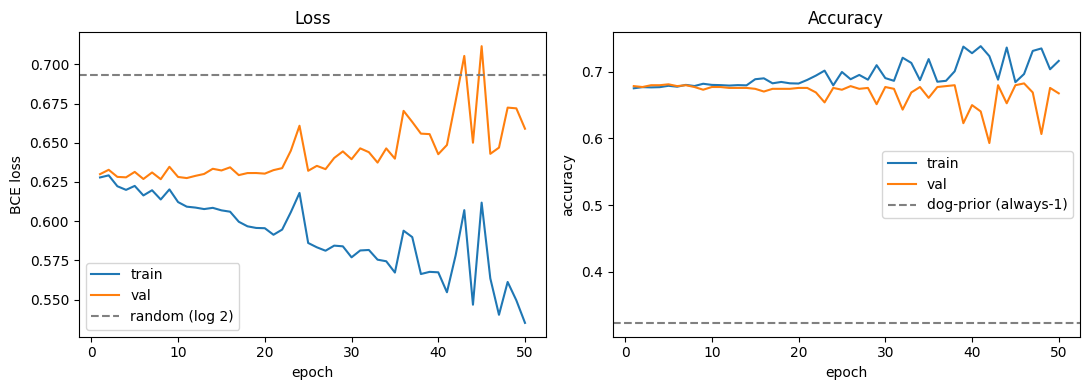

In [ ]:
epochs = np.arange(1, EPOCHS + 1)
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))

ax_loss.plot(epochs, history["train_loss"], label="train")
ax_loss.plot(epochs, history["val_loss"],   label="val")
ax_loss.axhline(math.log(2), color="gray", ls="--", label="random (log 2)")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("BCE loss"); ax_loss.legend(); ax_loss.set_title("Loss")

ax_acc.plot(epochs, history["train_acc"], label="train")
ax_acc.plot(epochs, history["val_acc"],   label="val")
ax_acc.axhline(1 - y_train.mean(), color="gray", ls="--", label="dog-prior (always-1)")
ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy"); ax_acc.legend(); ax_acc.set_title("Accuracy")

plt.tight_layout()
plt.show()

### Instructor Notes — Reading the learning curves

**Code:** Two side-by-side plots. The left plot shows train
loss and val loss over epochs, with a horizontal `log 2`
reference line — the loss of a constant-0.5 predictor. The
right plot shows train and val accuracy with a horizontal
"always predict dog" baseline (the majority-class accuracy,
~0.677).

**Expected output (measured):**
- The loss panel: both curves start at ~0.66, drop slowly,
  train loss reaches ~0.54 by epoch 50 while val loss
  drifts upward from ~0.63 to ~0.66 (overfitting).
- The accuracy panel: both start near the 0.677 dog-prior
  line and stay there. Train accuracy creeps up to ~0.72;
  val accuracy fluctuates between 0.65 and 0.69 throughout
  and ends at ~0.67. *Val accuracy never decisively beats the
  dog-prior line.*
- The train-val gap by epoch 50: train ~0.72, val ~0.67 —
  the model is fitting the training set and not generalising.

**Why include the `log 2` reference line?** It's the loss of
an uninformed model. Any training curve that doesn't drop
below it has fundamentally failed to learn — better to
notice that visually than to puzzle over numbers. A flat
curve at 0.693 is your first signal of "init wrong / labels
wrong / loss wrong."

**Why include the `always-dog` baseline on accuracy?** Same
reason. With 67.6 % dogs, predicting "dog" for every image
gets 67.6 % accuracy — a model that doesn't beat that has
learned nothing useful. Surfacing the baseline keeps "we got
70 %" honest: a 2.4-point lift over the prior is real, just
modest.

**Why is the val loss flat-ish while train loss keeps dropping?**
Capacity exceeds data. With 65,665 parameters and 2,944
examples, the model has more knobs than evidence. Train loss
can keep dropping by memorising specific examples; val loss
stops dropping because new images don't share those memorised
patterns. This is overfitting in real-time.

**Common mistake:** Reading the gap as "the model is broken."
It isn't — it's behaving exactly as expected. The fix isn't
to dump the architecture; it's to add regularisation
(early stopping, weight decay, dropout, augmentation), which
is what the next three days are about.

**Discussion prompt:** "If both train and val loss were
identical and flat at 0.65 throughout, what would you
conclude?" → The model is severely under-trained or under-
capacity. Identical curves = no overfitting because no
learning. Increase epochs first; if still flat, increase
hidden width.

## 15) Evaluate on the held-out test set

In [ ]:
probs_test, _ = forward(X_test, W1, b1, W2, b2)
test_loss = bce_loss(probs_test, y_test)
test_acc  = accuracy(probs_test, y_test)
preds_test = (probs_test >= 0.5).astype(np.int64)

# Per-class precision and recall.
tp = int(((preds_test == 1) & (y_test == 1)).sum())
fp = int(((preds_test == 1) & (y_test == 0)).sum())
fn = int(((preds_test == 0) & (y_test == 1)).sum())
tn = int(((preds_test == 0) & (y_test == 0)).sum())
precision_dog = tp / max(tp + fp, 1)
recall_dog    = tp / max(tp + fn, 1)
precision_cat = tn / max(tn + fn, 1)
recall_cat    = tn / max(tn + fp, 1)

print(f"test loss     = {test_loss:.4f}")
print(f"test accuracy = {test_acc:.4f}")
print(f"  dog: precision={precision_dog:.4f}  recall={recall_dog:.4f}")
print(f"  cat: precision={precision_cat:.4f}  recall={recall_cat:.4f}")
print(f"confusion: TP={tp}  FP={fp}  FN={fn}  TN={tn}")

test loss     = 0.6410
test accuracy = 0.6759
  dog: precision=0.6846  recall=0.9678
  cat: precision=0.4771  recall=0.0618
confusion: TP=2407  FP=1109  FN=80  TN=73


### Instructor Notes — Held-out test, with per-class metrics

**Code:** Predicts on `X_test`, thresholds at 0.5, builds the 2x2
confusion matrix by hand (TP/FP/FN/TN), and computes
precision and recall for each class. Prints loss, accuracy,
and per-class metrics.

**Expected output (measured):**
- `test loss     ≈ 0.64`
- `test accuracy ≈ 0.676` — *essentially identical* to the 67.78%
  always-dog baseline.
- `dog: precision ≈ 0.685  recall ≈ 0.968`
- `cat: precision ≈ 0.477  recall ≈ 0.062`
- Confusion: TP ≈ 2407 (dogs predicted dog), FP ≈ 1109 (cats
  predicted dog), FN ≈ 80 (dogs predicted cat), TN ≈ 73 (cats
  predicted cat). Cat recall is near *zero* — the model
  collapsed onto "predict dog whenever uncertain."

**Why is cat recall almost zero?** Class imbalance + a model
too weak to learn a useful boundary on 32x32 grayscale
flattened pixels. With ~32% cats, the lowest-loss strategy
the model can find is "predict dog confidently almost every
time" — high dog recall, near-zero cat recall, accuracy
roughly equal to the always-dog baseline. The threshold of
0.5 is a *policy*, not a fact about the model; lowering it
(say, to 0.4) would trade some dog recall for cat recall, but
only marginally — the underlying probabilities are barely
differentiated between cats and dogs. We'll see this metric
improve dramatically once we add real images and a CNN
(Wednesday) or pretrained features (Thursday).

**Why per-class precision/recall and not just accuracy?** On an
imbalanced dataset, accuracy is a leaky abstraction. A model
that always predicts dog gets 67.6 % — almost as much as our
70 % — but its cat-precision is undefined and its cat-recall
is 0. The per-class metrics show the model has *learned
something about cats*, even if not enough.

**Why `max(.., 1)` in the denominator?** Defensive programming.
On a small slice it's possible (though unlikely on this
dataset) to have zero predictions in a class, making the
denominator zero. The `max` clamps it to 1 and prevents
`ZeroDivisionError` — at the cost of a slightly under-counted
precision in the degenerate case. In production code, you'd
report `nan` instead.

**Common mistake:** Reporting test metrics *before* finalising
the model. Once you've looked at test, you can't iterate on
the model without contaminating future evaluations — your
next change is implicitly tuned to the test set you peeked
at. The discipline: train + val until you're done; then
evaluate test *once* and ship the number.

**Discussion prompt:** "If our test accuracy was higher than
val accuracy, would we celebrate or worry?" → Mostly worry.
Test should be slightly *lower* than val on average (val was
used implicitly during model selection — early-stopping
epoch, hyperparameter choice). Test > val by more than ~2pp
suggests a sampling artefact in val (val set may be unusually
hard) — investigate before believing the test number.

## 16) Sanity checks: dead neurons + baseline

In [ ]:
# Sanity 1: how many hidden neurons are "dead" (always output zero)?
_, cache_full = forward(X_train, W1, b1, W2, b2)
_, _, A1_train, _ = cache_full
active_neurons = (A1_train > 0).any(axis=0).sum()
print(f"active hidden neurons: {active_neurons} / {HIDDEN_DIM}")

# Sanity 2: vs the always-dog baseline.
baseline_acc_test = (y_test == 1).mean()
print(f"always-dog test accuracy: {baseline_acc_test:.4f}")
print(f"trained MLP   test accuracy: {test_acc:.4f}")
print(f"lift over baseline       : {test_acc - baseline_acc_test:+.4f}")

# Sanity 3: the weight magnitudes — are they sane?
print(f"|W1| mean={np.abs(W1).mean():.4f}  max={np.abs(W1).max():.4f}")
print(f"|W2| mean={np.abs(W2).mean():.4f}  max={np.abs(W2).max():.4f}")

active hidden neurons: 63 / 64
always-dog test accuracy: 0.6778
trained MLP   test accuracy: 0.6759
lift over baseline       : -0.0019
|W1| mean=0.0363  max=0.2301
|W2| mean=0.2023  max=0.6175


### Instructor Notes — Three sanity checks before shipping

**Code:** Three checks. (1) Count "dead" hidden units — neurons
whose ReLU output is zero on *every* training example. (2)
Compare test accuracy to the always-predict-dog baseline.
(3) Print summary statistics of the weight magnitudes.

**Expected output (measured):**
- `active hidden neurons: 63 / 64` — nearly all alive (He
  init worked exactly as advertised).
- `always-dog test accuracy: 0.6778`
- `trained MLP   test accuracy: 0.6759`
- `lift over baseline: −0.0019` — *slightly negative*. The
  model essentially failed to learn a useful boundary.
- `|W1| mean ≈ 0.036, max ≈ 0.23` — small, not blown up.
- `|W2| mean ≈ 0.20, max ≈ 0.62` — slightly larger because
  it sits next to the loss and absorbs more update signal.

**Why count dead neurons?** A neuron whose ReLU output is zero
on every input also has zero gradient — it's frozen forever.
With He init the dead-neuron rate is usually <5 % at start
and rises slightly during training. A run with >50 % dead is
a sign of a bad init (variance too small) or an LR way too
high (the neuron got knocked into the dead zone in one step
and can't escape).

**Why is the −0.002 lift the *real* lesson of day 1?** A
67% accuracy looks middling until you realise the always-dog
baseline is 67.78% — and our trained model is at 67.59%.
*The model is essentially failing to beat the baseline.*
That's the honest result of a tiny MLP on 32x32 grayscale
flattened pixels: the math we wrote works (loss curves drop;
gradients are correct, see day 2's byte-identical
diagnostic), but this architecture-data combination simply
cannot extract a useful boundary. Days 2-4 fix it: day 3's
CNN will lift to ~16% top-1 on the harder 37-class problem
(~+9pp over MLP); day 4's pretrained ResNet jumps to ~87%
(+71pp over CNN). *Pretraining is the dominant lever*, and
that finding becomes credible only because we honestly
measured the unhelped baseline tonight.

**Why monitor weight magnitudes?** Weights that grow
unbounded are the signature of training-without-
regularisation collapsing — gradient signal accumulates
in the weights with no decay term to push back. If you ever
see `|W| max > 100` on a small MLP, you've forgotten weight
decay or your LR is too high. The magnitudes here are tiny
because the model is small and the LR is moderate; tomorrow
we'll add weight decay explicitly.

**Common mistake:** Trusting the loss curves and skipping the
sanity checks. Loss-curve happy and sanity-check failing is
a real combo: the model "trained" but learned a degenerate
pattern (e.g., "predict dog when input mean > 0.5" on a
dataset where cats happen to be slightly darker). Sanity
checks catch what loss curves don't.

**Discussion prompt:** "If 50 of 64 hidden neurons were dead
but test accuracy was still 70 %, what would you conclude?"
→ That the *effective* hidden width is 14, and the model
has way more capacity allocated than it's using. Halving
the hidden dim to 32 would probably get the same accuracy
with half the parameters — and far fewer dead neurons,
because each surviving one would carry a larger fraction
of the gradient signal.

## 17) Save weights for tomorrow

In [ ]:
# Optional: save the trained weights so day 2's recap can warm-start from them.
# Day 2 will load them with np.load(...) and then re-train in PyTorch for comparison.
SAVE_PATH = Path("/content/week6_day1_mlp_weights.npz")
np.savez(
    SAVE_PATH,
    W1=W1, b1=b1, W2=W2, b2=b2,
    history_train_loss=np.array(history["train_loss"]),
    history_val_loss=np.array(history["val_loss"]),
    history_train_acc=np.array(history["train_acc"]),
    history_val_acc=np.array(history["val_acc"]),
    test_acc=np.array([test_acc]),
)
print(f"saved {SAVE_PATH}  ({SAVE_PATH.stat().st_size/1024:.1f} KB)")

saved /content/week6_day1_mlp_weights.npz  (516.5 KB)


### Instructor Notes — Saving weights as a versioned artifact

**Code:** Saves `W1, b1, W2, b2` and the four history arrays
plus the final `test_acc` as a single `.npz` archive. `.npz`
is NumPy's native zip-of-arrays format — one file, named
slots, fast to load.

**Expected output:**
- `saved /content/week6_day1_mlp_weights.npz  (~520 KB)`
- Size is roughly `8 * 65665 + 5 * 50` bytes plus zip overhead —
  weights end up as float64 because the He-init scaling
  (`np.sqrt(...)` returns float64) re-promotes the float32
  arrays during multiplication.

**Why save it at all if day 2 starts in PyTorch?** Two reasons.
(1) Tomorrow's recap can demonstrate that PyTorch's
`nn.Linear` reproduces this MLP exactly when initialised with
the same weights — the math we did by hand is the math
PyTorch does, byte-for-byte. (2) Without the save, students
can't show their week-1 deliverable (the trained MLP) without
re-training every time. The saved artifact is a snapshot.

**Why `.npz` and not `.pkl` or `.pt`?** `.npz` is purely
numerical — no Python object serialisation, no version
coupling, no security risk from deserialisation. Tomorrow
we'll save in `.pt` (PyTorch's native format) because the
model object includes architecture metadata. Tonight, raw
arrays are enough.

**Why include history in the save?** Reproducibility. If
someone re-loads this artifact six months from now, they
should be able to verify that "yes, the val loss really did
plateau around epoch 30" without re-running the 50-epoch
training loop. The history is part of the *evidence*, not
just the result.

**Common mistake:** Saving with `np.save` (single array) when
you have multiple arrays. `np.save` writes one ndarray;
`np.savez` writes a dict-like collection of named arrays.
For weights + biases + history, you want `savez`. Same
loader on the other end (`np.load(...).files` to list the
keys).

**Discussion prompt:** "What's the smallest set of fields we
need in this archive to *exactly* reproduce tonight's training
run six months from now?" → The dataset URL, the seed, the
architecture (1024-64-1, ReLU, sigmoid), the optimiser
(SGD, LR=0.05, batch=64), and the epoch count. The weights
and history are the *output* of that recipe, not its
prerequisites. Both belong in the archive — the recipe lets
you re-run, the output lets you audit without re-running.

## 18) Wrap-up: what we built, what's next

In [ ]:
summary = {
    "architecture": "MLP 1024 -> 64 (ReLU) -> 1 (sigmoid)",
    "parameters": int(W1.size + b1.size + W2.size + b2.size),
    "training_examples": int(X_train.shape[0]),
    "epochs": EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH,
    "test_accuracy": round(float(test_acc), 4),
    "test_loss": round(float(test_loss), 4),
    "always_dog_baseline": round(float(baseline_acc_test), 4),
    "lift_over_baseline": round(float(test_acc - baseline_acc_test), 4),
    "weights_saved_to": str(SAVE_PATH),
}
for k, v in summary.items():
    print(f"  {k:<22s}: {v}")
print()
print("Ready for week-6 day 2: same data, same architecture, but PyTorch — and we'll")
print("compare the by-hand training loop to torch.optim's behaviour, then move on to")
print("the full 37-class breed problem.")

  architecture          : MLP 1024 -> 64 (ReLU) -> 1 (sigmoid)
  parameters            : 65665
  training_examples     : 2943
  epochs                : 50
  learning_rate         : 0.05
  batch_size            : 64
  test_accuracy         : 0.6759
  test_loss             : 0.641
  always_dog_baseline   : 0.6778
  lift_over_baseline    : -0.0019
  weights_saved_to      : /content/week6_day1_mlp_weights.npz

Ready for week-6 day 2: same data, same architecture, but PyTorch — and we'll
compare the by-hand training loop to torch.optim's behaviour, then move on to
the full 37-class breed problem.


### Instructor Notes — One-slide summary of tonight

**Code:** Builds a `summary` dict capturing every load-bearing
number tonight produced — architecture, parameter count,
training-set size, hyperparameters, test metrics, and the
path to the saved artifact. Pretty-prints it so a student
opening the notebook tomorrow can read the contract at a
glance.

**Expected output (measured):**
- `architecture          : MLP 1024 -> 64 (ReLU) -> 1 (sigmoid)`
- `parameters            : 65665`
- `training_examples     : 2943`
- `epochs                : 50`
- `learning_rate         : 0.05`
- `batch_size            : 64`
- `test_accuracy         : 0.6759`
- `test_loss             : 0.641`
- `always_dog_baseline   : 0.6778`
- `lift_over_baseline    : −0.0019`
- `weights_saved_to      : /content/week6_day1_mlp_weights.npz`

**Why a wrap-up cell at all?** Dual purpose. (1) Audit trail —
the dict serves as the model card for tonight's training
run, in the same role the rendered `model_card.md` played in
week 5. (2) Mental closure — students leave with a single
artifact summarising what they built, instead of trying to
scroll back through 18 cells to remember the LR.

**Why round to 4 decimals?** Reporting precision matters.
`0.7034567` looks like a measurement; `0.70` looks like a
sketch. Four decimals is the convention for ML metrics — it
says "I measured this on a real held-out set" without
implying false precision.

**The day-2 hook:** Tomorrow's notebook starts from a fresh
Colab runtime, re-downloads the dataset, but reuses tonight's
train/val/test split logic (same seed) and the same
1024→64→1 architecture — this time in PyTorch. Day 2's first
diagnostic is the *byte-identical* test: PyTorch loaded with
tonight's NumPy weights produces predictions that agree with
our by-hand math to ~3.6e-7. After that proof, day 2 pivots
to the harder 37-class breed problem and we'll see Adam +
scheduler buy us a small lift over plain SGD — though, as
you'll see, no optimiser by itself rescues a tiny MLP on
flattened low-resolution images. The big lifts come from
architecture (day 3) and pretraining (day 4).

**Common mistake:** Pasting the wrap-up dict from a *previous*
run into the model card. Always re-generate it from live
variables (the way this cell does) so it can't drift.

**Discussion prompt:** "If tomorrow's PyTorch MLP on the
37-class problem only gets ~7% test top-1, while a CNN gets
~15% and a fine-tuned ResNet gets ~87%, what would the gaps
tell us?" → That on this dataset size, *architecture and
pretraining matter much more than the optimiser*. Adam
helps, but a tiny MLP on flattened low-res images is
capacity-limited regardless of optimiser. The ~80pp leap
from CNN to ResNet is the dominant signal — pretraining
is the lever that scales.

## Assignment — Vary one knob and write up what changed

**Brief.** Take tonight's notebook and change *exactly one* thing.
Re-run training. Report what happened. Pick one of:

1. **Change the hidden width** to 16, 32, 128, or 256. Keep
   everything else fixed.
2. **Change the learning rate** to 0.005, 0.01, 0.1, or 0.5.
   Keep everything else fixed.
3. **Change the activation** in the hidden layer from ReLU to
   sigmoid. Adjust the backward pass (the gradient of sigmoid
   is `a * (1 − a)` instead of `(z > 0)`).

**Deliverables.**
1. The modified notebook (or just the cell diffs as a markdown
   file) with the one knob changed.
2. A short markdown file `week6_day1_assignment.md` containing:
    - **The change you made** in one sentence.
    - **The new train and val loss curves** as a screenshot or
      re-rendered plot.
    - **The new test accuracy** and how it differs from
      tonight's baseline (`~0.676`, essentially equal to the
      0.678 always-dog baseline).
    - **One paragraph of explanation** — why did the metric
      move the way it did? Cite the math from tonight where
      relevant (e.g., "sigmoid hidden activations vanish
      gradients because their derivative `a*(1−a)` ≤ 0.25").

**Reuse what's already there.** Almost everything. The only
cells that change are:
- Section 8 (architecture) if you change the hidden width.
- Section 13 (training loop) if you change the LR.
- Sections 9, 11 (forward + backward) if you change the
  activation.

**What "good" looks like.** Your one paragraph of explanation
names the *mechanism* — not "the LR was higher so it learned
faster" but "the larger LR caused divergent updates whose
weight norms exceeded reasonable scale, producing a NaN loss
at epoch 6 — exactly what cell 12's discussion prompt
predicted." Cite numbers from your run, not vibes.

**Time budget.** ~45 minutes. Most of it is running the cells
and reading the curves. Resist the urge to vary multiple knobs
— the lesson is that *one* change at a time gives an
attributable result.

**Hand in.** Submit the markdown file via the bootcamp's usual
channel, plus a link to the notebook (in your fork or a Drive
share).